# Summary of lecture 3

Yesterday we discretized a random dynamical system with additive uniform noise on the Ulam basis, we bounded the norms of the powers of the discretized annealed operator on the space of vectors of average zero, we transported those bounds from a coarse partition to a fine one, and we turned the residual of an approximate fixed point into a rigorous $L^1$ bound on the distance from the stationary density.
With that bound and a splitting of the space we enclosed the Lyapunov exponent of a family of unimodal maps at two noise sizes, one enclosure positive and the other negative.

Those norms are a mixing rate: a certified statement that after $n$ steps the operator has contracted every zero average density by a factor $\eta_n$.
Today the mixing rate is the object we go after, and the density and the Lyapunov exponent come out of it.

# A certified mixing rate

We work with the family
$$
T_{\alpha,\beta}(x) = \beta - (1+\beta)|x|^{\alpha}, \qquad \alpha \geq 1,\ \beta \in (-1, 1],
$$
on $[-1,1]$, perturbed by additive Gaussian noise of standard deviation $\sigma$, with the boundary condition that identifies $x$ with $x+2$; the technique is the one of [Galatolo, Lopez Vereau, Marangio, Nisoli, *Efficient computation of stationary measures and the Lyapunov landscape for families of random dynamical systems with smooth additive noise*](https://doi.org/10.1137/25M1786441), and the implementation is the one packaged in `PlateauExperiment.jl`.

The annealed transfer operator is again $P_\sigma f = \rho_\sigma * (Pf)$, and the reason to change basis is that convolution is multiplication frequency by frequency:
$$
\mathcal{F}(\rho_{\sigma}*f)[k] = e^{-\sigma^2 k^2 \pi^2/2}\,\mathcal{F}(f)[k].
$$
Since $P$ is a weak contraction of $L^1$, every $f \in L^1$ is sent by $P_\sigma$ to a function whose Fourier coefficients decay like $e^{-\sigma^2 k^2\pi^2/2}$; the operator is smoothing, the truncation at frequency $K$ costs an error that is exponentially small in $K^2$, and a matrix of size $2K+1$ is enough.

## Setting up

In [2]:
import Pkg
Pkg.activate("./")
Pkg.add(["RigorousInvariantMeasures", "BallArithmetic", "IntervalArithmetic",
         "FFTW", "TaylorModels", "Plots", "RecipesBase", "LaTeXStrings"])

  Activating project at `~/Code/HSI`
     Project No packages added to or removed from `~/Code/HSI/Project.toml`
    Manifest No packages added to or removed from `~/Code/HSI/Manifest.toml`


In [3]:
using RigorousInvariantMeasures, IntervalArithmetic, BallArithmetic
using LinearAlgebra, FFTW, TaylorModels
using BallArithmetic.CertifScripts
using Plots, RecipesBase, LaTeXStrings

import IntervalArithmetic: inf, sup, mid, radius, diam, interval

setdisplay(:infsup; decorations = false, ng_flag = false)

┌ Info: Switching to OpenBLAS with ConsistentFPCSR = 1 flag enabled, guarantees
│         correct floating point rounding mode over all threads.
└ @ BallArithmetic /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/BallArithmetic.jl:37
┌ Info: OpenBLAS is giving correct rounding on a (1024,1024) test matrix on 64 threads
└ @ BallArithmetic /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/BallArithmetic.jl:44


Generating forwards to /home/isaia/.julia/artifacts/497c61a1c5c3d838edfd8d4b4cf847a31dabf1d0/lib/libopenblas64_.so (clear: 0, verbose: 1, suffix_hint: '(null)')
 -> Autodetected symbol suffix "64_"
 -> Autodetected interface ILP64 (64-bit)
 -> Autodetected normal complex return style
 -> Autodetected gfortran calling convention
 -> CBLAS detected
Processed 5146 symbols; forwarded 5067 symbols with 64-bit interface and mangling to a suffix of "64_"


Display options:
  - format: infsup
  - decorations: false
  - NG flag: false
  - significant digits: 6

We fix the parameters and build the basis. `FourierAdjoint(K, FFTNx)` is a Fourier basis truncated at the frequencies $-K, \dots, K$, which assembles the transfer operator through a discretization of its adjoint; the adjoint is the composition operator $f \mapsto f\circ T$, so the dynamic may be handed over as an ordinary function rather than as a piecewise map with its branches. The change of variables sends the system from $[-1,1]$ to $[0,1]$.

In [4]:
α = interval(3.5)
β = interval(1)
K = 128
FFTNx = 1024

B = FourierAdjoint(K, FFTNx)

┌ Warning: This basis breaks the usual interface of the package, i.e.,
│     the dynamic is input as a function instead than a PwMap
└ @ RigorousInvariantMeasures /home/isaia/.julia/packages/RigorousInvariantMeasures/snZmj/src/Basis/Fourier/FourierAdjoint.jl:22


FourierAdjoint on 1024 points, freq 128, strong=Cω(), weak=L2()

In [5]:
τ₁(x) = (x+1)/2          # from [-1, 1] to [0, 1]
τ₂(x) = 2*x-1            # from [0, 1] to [-1, 1]

T_pm(x) = β - (1+β)*abs(x)^α
T(x) = τ₁(T_pm(τ₂(x)))

T (generic function with 1 method)

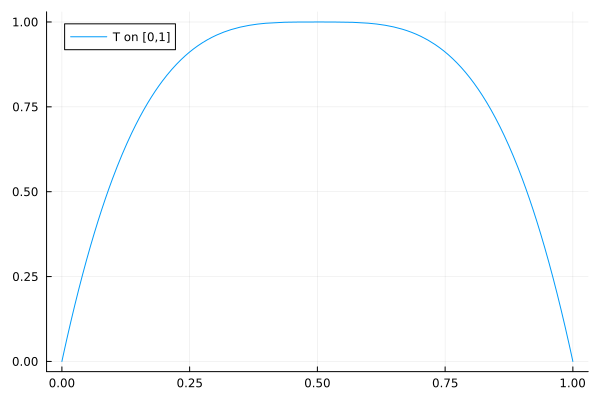

In [6]:
plot(x -> IntervalArithmetic.mid(T(x)), 0, 1; label = "T on [0,1]")

In [7]:
@time PK = assemble(B, T)

  1.690458 seconds (7.22 M allocations: 391.718 MiB, 17.90% gc time, 93.78% compilation time)


257×257 Matrix{Complex{Interval{Float64}}}:
 [0.999999, 1.00001] + im*[-2.17604e-14, 2.17604e-14]  …  [-2.17604e-14, 2.17604e-14] + im*[-2.17604e-14, 2.17604e-14]
      [0.474773, 0.474774] + im*[0.186617, 0.186618]                 [-0.375593, -0.375592] - im*[0.0188691, 0.0188692]
      [0.392084, 0.392085] + im*[0.166867, 0.166868]                 [-0.340098, -0.340097] - im*[0.0599437, 0.0599438]
      [0.349747, 0.349748] + im*[0.153616, 0.153617]                  [-0.31428, -0.314279] - im*[0.0732258, 0.0732259]
      [0.322351, 0.322352] + im*[0.144072, 0.144073]                 [-0.295305, -0.295304] - im*[0.0788739, 0.078874]
      [0.302536, 0.302537] + im*[0.136744, 0.136745]   …             [-0.280603, -0.280602] - im*[0.0815036, 0.0815037]
      [0.287232, 0.287233] + im*[0.130862, 0.130863]                  [-0.26874, -0.268739] - im*[0.082702, 0.0827021]
      [0.274888, 0.274889] + im*[0.125986, 0.125987]                 [-0.258872, -0.258871] - im*[0.0831446, 0.0831447]

## Ball arithmetic

The assembled matrix is a matrix of complex intervals, and every operation we are about to perform on it is linear algebra: products, an eigendecomposition, singular values.
An interval matrix carries two endpoints per real and per imaginary part and cannot use the machine's matrix multiplication; a ball matrix carries a centre matrix and a radius matrix, so the centre product is one call to the tuned floating point routine and the radius is bounded afterwards by a few norm inequalities. We convert once, and we stay in ball arithmetic for the rest of the notebook; loading `IntervalArithmetic` beside `BallArithmetic` brings in the conversion, so `BallMatrix` applied to a matrix of intervals is all that we need, and on a complex matrix it returns the disc that contains the rectangle, with the radius rounded up.

In [8]:
bPK = BallMatrix(PK)
maximum(bPK.r)

3.6127827474313666e-13

Convolution with the noise is diagonal in this basis, with the entries written above; we build it as an interval matrix and convert it the same way.

In [9]:
σ = interval(0.1)

NoiseInterval(σ, K) = Diagonal([[exp((-σ^2*interval(π)^2*interval(k)^2)/2) for k in 0:K];
                                [exp((-σ^2*interval(π)^2*interval(k)^2)/2) for k in -K:-1]])
bD = BallMatrix(NoiseInterval(σ, K))

257×257 BallMatrix{Float64, Float64, Ball{Float64, Float64}, Diagonal{Float64, Vector{Float64}}, Diagonal{Float64, Vector{Float64}}}:
 1.0 ± 0.0  …              0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0  …              0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
                                ⋮  ⋱  
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0  …              0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0                 0.0 ± 0.0
 0.0 ± 0.0  …              0.0 ± 0.0
 0.0 ± 0.0     0.95185 ± 1.11022e-16

In [10]:
PσK = bD*bPK

257×257 BallMatrix{Float64, ComplexF64, Ball{Float64, ComplexF64}, Matrix{ComplexF64}, Matrix{Float64}}:
               1.0+0.0im ± 6.18601e-14  …                 0.0+0.0im ± 6.15476e-14
     0.451913+0.177632im ± 6.23753e-14        -0.357508-0.0179606im ± 6.22594e-14
      0.32185+0.136976im ± 5.67572e-14         -0.279175-0.049206im ± 5.66814e-14
     0.224321+0.0985269im ± 4.7802e-14        -0.201573-0.0469656im ± 4.77266e-14
    0.146361+0.0654147im ± 3.46336e-14          -0.13408-0.035812im ± 3.46014e-14
   0.0881025+0.0398218im ± 2.40736e-14  …    -0.0817152-0.0237349im ± 2.40501e-14
   0.0486068+0.0221451im ± 1.47134e-14       -0.0454773-0.0139952im ± 1.46998e-14
   0.0244911+0.0112248im ± 8.36637e-15      -0.0230642-0.00740777im ± 8.35798e-15
  0.0112461+0.00517839im ± 3.85499e-15      -0.0106448-0.00353424im ± 3.84959e-15
 0.00469973+0.00217223im ± 1.81875e-15     -0.00446677-0.00152309im ± 1.81699e-15
                                                               ⋮  ⋱  
 0.00

The two heatmaps below plot $-\log|M_{ij}|$, so a light colour means an entry that is exponentially small; the second one shows what the noise does to the high frequencies. The colour scales are not the same.

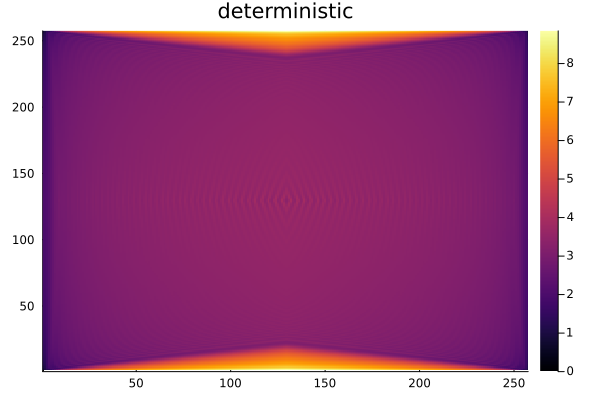

In [11]:
heatmap(-log.(abs.(BallArithmetic.mid.(bPK))); title = "deterministic")

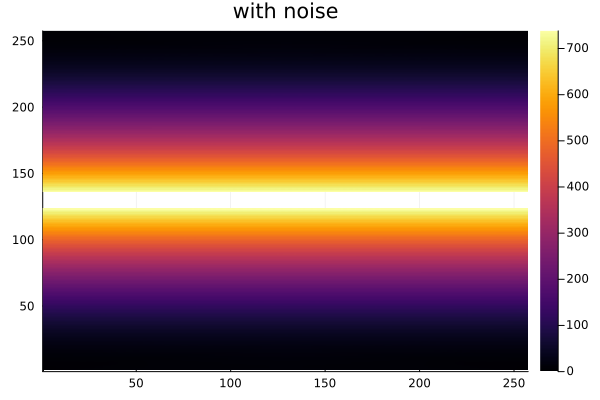

In [12]:
heatmap(-log.(abs.(BallArithmetic.mid.(PσK))); title = "with noise")

## The stationary density

We compute an approximate fixed point from the centre matrix, with an ordinary eigendecomposition; nothing here needs to be rigorous, since the error will be measured afterwards by the residual.

In [13]:
F = eigen(PσK.c)
p = sortperm(abs.(F.values), rev = true)
F.values[p][1:5]

5-element Vector{ComplexF64}:
                   1.0 + 0.0im
   -0.4900231549726227 - 5.551115123125783e-17im
 -0.024028583179909527 + 0.14996656065810363im
  -0.02402858317990934 - 0.1499665606581019im
  0.010102934835708993 - 8.883414837068671e-13im

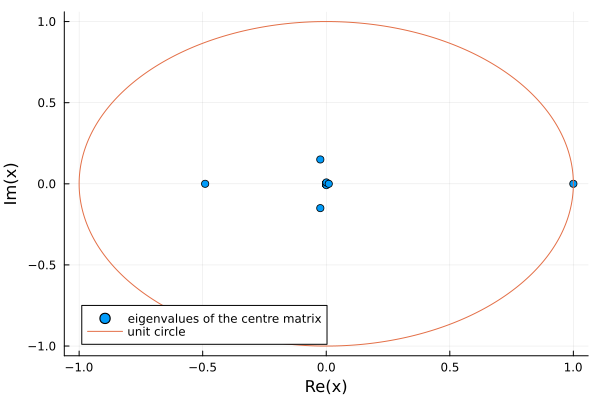

In [14]:
scatter(F.values; label = "eigenvalues of the centre matrix")
plot!([cos(t) for t in 0:0.01:2π], [sin(t) for t in 0:0.01:2π]; label = "unit circle")

The leading eigenvalue is $1$, since the operator preserves the integral, and we normalise the corresponding eigenvector so that its zeroth coefficient is $1$.
The Fourier coefficients of a real function satisfy $\hat f[-k] = \overline{\hat f[k]}$, and the numerical eigenvector loses that symmetry; we impose it, which costs nothing and makes the density real.

In [15]:
fσK = F.vectors[:, p[1]]
fσK /= fσK[1]

function symmetrise(v)
    w = zeros(eltype(v), length(v))
    N = (length(v)-1) ÷ 2
    w[1:N+1] = v[1:N+1]
    w[end-N+1:end] = [x' for x in reverse(v[2:N+1])]
    return w
end

fσKs = symmetrise(fσK)
bf = BallVector(fσKs)

257-element BallVector{Float64, ComplexF64, Ball{Float64, ComplexF64}, Vector{ComplexF64}, Vector{Float64}}:
                                    1.0 + 0.0im ± 0.0
   0.3008847126379131 + 0.0003333049796571258im ± 0.0
    0.20273131252096163 + 0.05909996062902812im ± 0.0
    0.14255645707862294 + 0.04795564427084301im ± 0.0
   0.09316578988777777 + 0.034007179277844996im ± 0.0
    0.05609461592493155 + 0.02150091446097611im ± 0.0
  0.030945869002085038 + 0.012258213791861539im ± 0.0
 0.015590105086307456 + 0.0063249555490885595im ± 0.0
  0.00715753385442592 + 0.0029574508107007287im ± 0.0
 0.002990598260352358 + 0.0012537883058985758im ± 0.0
                                                                              ⋮
 0.002990598260352358 - 0.0012537883058985758im ± 0.0
  0.00715753385442592 - 0.0029574508107007287im ± 0.0
 0.015590105086307456 - 0.0063249555490885595im ± 0.0
  0.030945869002085038 - 0.012258213791861539im ± 0.0
    0.05609461592493155 - 0.02150091446097611im ± 0.0
 

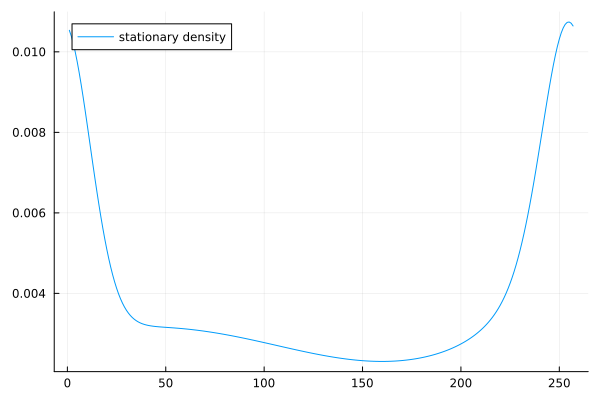

In [16]:
plot(real.(ifft(BallArithmetic.mid(bf))); label = "stationary density")

The residual is computed in ball arithmetic, and it is the only place where the approximate eigenvector meets a rigorous operation; $\epsilon$ below bounds $\|P_{\sigma,K} f_{\sigma,K,s} - f_{\sigma,K,s}\|_{L^2}$.

In [17]:
res = PσK*bf - bf
ε = norm(res.c, 2) + norm(res.r, 2)

1.024004160222361e-12

# The mixing rate

Let $V$ be the subspace of $L^2$ of average zero, which is invariant under the annealed operator; a mixing rate is a pair $(n, \eta)$ with
$$
\big\|P_{\sigma,K}^{\,n}\big|_V\big\|_{L^2\to L^2} \leq \eta < 1,
$$
proved, not observed. In the truncated basis the restriction to $V$ is the matrix with the first row and the first column removed, since the zeroth coefficient is the integral.

The eigenvalues we plotted give a candidate answer, the second largest modulus; that answer is wrong at finite $n$, and we shall see by how much.

In [18]:
A = PσK[2:end, 2:end]
size(A)

(256, 256)

`svd_bound_L2_opnorm` returns a rigorous upper bound for the largest singular value of a ball matrix, computed from a floating point singular value decomposition and a perturbation bound; we apply it to the powers.

In [19]:
function power_norms(A, N)
    norms = zeros(N)
    Ai = A
    for i in 1:N
        norms[i] = BallArithmetic.svd_bound_L2_opnorm(Ai)
        Ai = Ai*A
    end
    return norms
end

power_norms (generic function with 1 method)

In [20]:
@time norms = power_norms(A, 12)

  7.689522 seconds (10.61 M allocations: 5.058 GiB, 35.63% gc time, 43.50% compilation time)


12-element Vector{Float64}:
 1.1899603133828005
 0.9192775043180043
 0.6272456337205718
 0.3610054984934667
 0.18505266784850874
 0.08935416746697815
 0.04349513136529325
 0.021329435879191665
 0.010459314152800155
 0.005125540666223475
 0.0025124381975905525
 0.0012349873977600505

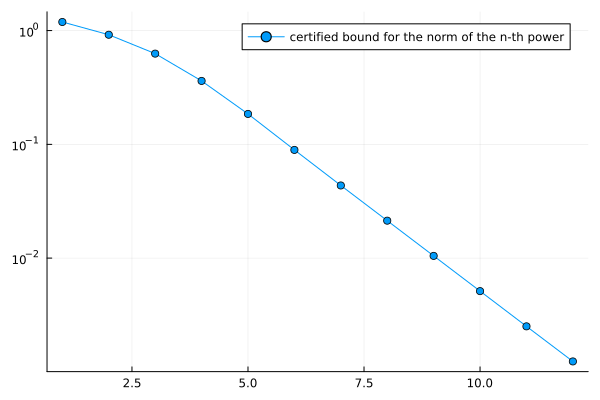

In [21]:
plot(1:12, norms; yscale = :log10, marker = :circle,
     label = "certified bound for the norm of the n-th power")

In [22]:
n₁ = findfirst(<(1.0), norms)
η  = interval(norms[n₁])
n₁, η

(2, [0.919277, 0.919278])

The first power is expansive, with norm above $1$; the second contracts, and $(n_1, \eta) = (2, 0.9193)$ is the first certified mixing rate.
Taking the twelfth power instead gives a much better rate per step, and the comparison with the second eigenvalue is the following.

In [23]:
norms[end]^(1/12), maximum(abs.(F.values[p][2:end]))

(0.5723195005775711, 0.4900231549726227)

## Why the spectrum is not the answer

The operator is not normal, so its spectrum does not control the norms of its powers at finite time; the set of points where the resolvent exceeds $1/\varepsilon$, drawn below for a coarser truncation, reaches outside the unit circle although every eigenvalue lies well inside it, which is why $\|A\|$ is above one while the spectral radius is about one half.

In [24]:
Ksmall = 40
Bs = FourierAdjoint(Ksmall, 1024)
PKs = assemble(Bs, T)
As = (BallMatrix(NoiseInterval(σ, Ksmall))*BallMatrix(PKs)).c[2:end, 2:end]
size(As)

┌ Warning: This basis breaks the usual interface of the package, i.e.,
│     the dynamic is input as a function instead than a PwMap
└ @ RigorousInvariantMeasures /home/isaia/.julia/packages/RigorousInvariantMeasures/snZmj/src/Basis/Fourier/FourierAdjoint.jl:22


(80, 80)

  6.800642 seconds (283.37 k allocations: 2.269 GiB, 1.37% gc time, 1.07% compilation time)


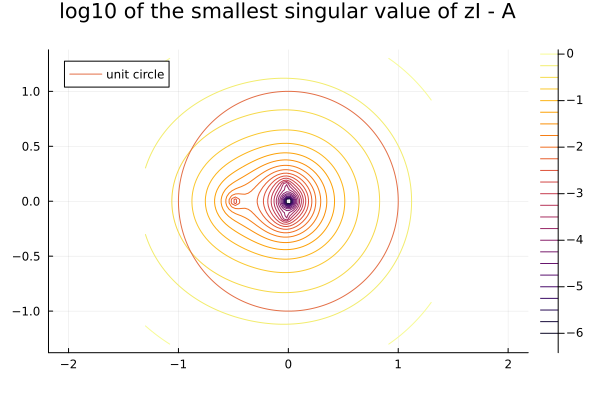

In [25]:
xs = range(-1.3, 1.3; length = 90)
ys = range(-1.3, 1.3; length = 90)
@time Z = [minimum(svdvals(As - (x+im*y)*I)) for y in ys, x in xs]
contour(xs, ys, log10.(Z); levels = -6:0.25:0.5, aspect_ratio = 1,
        title = "log10 of the smallest singular value of zI - A")
plot!([cos(t) for t in 0:0.01:2π], [sin(t) for t in 0:0.01:2π]; label = "unit circle")

The figure is drawn from floating point singular values and is not certified; the numbers above it are.

# From the mixing rate to the density

We use the following statement. Let $f_\sigma$ be the fixed point of $P_\sigma$, let $f_{\sigma,K,s}$ be the symmetrized approximate fixed point computed above, let $\epsilon$ bound its residual, and suppose there are $n$ and $\eta < 1$ with $\|P_{\sigma,K}^n|_V\|_{L^2\to L^2}\leq \eta$ and constants $C_i \geq \max(1, \|P_{\sigma,K}^i|_V\|)$ for $0 \leq i \leq n-1$. Then
$$
\|f_{\sigma}-f_{\sigma,K,s}\|_{L^{2}} \leq \frac{1}{1-\eta}\sum_{i=0}^{n-1}C_i\big(\delta_{\sigma,K} + \epsilon\big),
$$
where $\delta_{\sigma,K}$ collects the error made by truncating the Fourier expansion at $K$, namely
$$
\delta_{\sigma,K} = \Gamma_{\sigma,K}(1+\Gamma^1_{\sigma,K}) + \|\rho_\sigma\|_{L^2}\sqrt{\coth(1/2\sigma^2)}\,\Gamma^1_{\sigma,K},
$$
with $\Gamma_{\sigma,K}$ the $L^1 \to L^2$ tail bound and $\Gamma^1_{\sigma,K}$ the $L^1\to L^1$ one; both carry the factor $e^{-\sigma^2K^2\pi^2/2}$.

Both $n$ and the $C_i$ come out of the computation just done, and are not free parameters: $n$ is the first index at which the certified norm drops below one, $\eta$ is the norm there, and the $C_i$ are the earlier norms, raised to $1$ where they are smaller.

In [26]:
C = [interval(1.0); [interval(max(1.0, norms[i])) for i in 1:n₁-1]]

2-element Vector{Interval{Float64}}:
 [1.0, 1.0]
 [1.18996, 1.18997]

In [27]:
Iπ = interval(π)

Γ  = sqrt(coth(1/(2*σ^2))/(σ*sqrt(Iπ)))*exp((-σ^2*interval(K)^2*Iπ^2)/2)
Γ¹ = (2/(σ^2*Iπ^2*interval(K)))*exp((-σ^2*interval(K)^2*Iπ^2)/2)
ρ₂ = sqrt(1/(2*σ*sqrt(Iπ)))*sqrt(coth(1/(2*σ^2)))

δ = Γ*(1+Γ¹) + ρ₂*Γ¹

[0.0, 3.0e-323]

At $\sigma = 0.1$ and $K = 128$ the exponent $-\sigma^2K^2\pi^2/2$ is about $-808$, so $\Gamma$ underflows the smallest positive double and the enclosure of $\delta$ is $[0, 3\cdot 10^{-323}]$; the truncation contributes nothing here, and the residual $\epsilon$ is what the bound is made of.

In [28]:
R = (sum(C)*(δ+interval(ε)))/(1-η)

[2.77807e-11, 2.77808e-11]

# The Lyapunov exponent

The Lyapunov exponent of the random system is
$$
\lambda(\alpha,\beta,\sigma) = \int_{-1}^{1}\log|T'_{\alpha,\beta}|\,f_{\sigma}\,dm,
$$
and, since we work with Fourier coefficients, we need those of the observable:
$$
\mathcal{F}(\log|T'|)[0] = \log((1+\beta)\alpha)-(\alpha-1),\qquad
\mathcal{F}(\log|T'|)[j] = -\frac{\alpha-1}{j\pi}\int_0^{j\pi}\frac{\sin t}{t}\,dt.
$$
We enclose the integral by splitting it at the zeros of the sine: on $[0,\pi]$ we sum the alternating power series of the primitive of $\sin(t)/t$ and bound the remainder by the first omitted term, and on each later arch $[i\pi, (i+1)\pi]$ we use a Taylor model, exactly as in lecture 2.
We work in $256$ bits, since the power series at $0$ has terms with factorials in the denominator.

In [29]:
setprecision(256)
Pi = interval(BigFloat, π)

sinc_over(t) = sin(t)/t
tay(i, x) = x^(2i+1)/(interval(BigFloat, factorial(big(2i+1)))*interval(BigFloat, 2i+1))

tay (generic function with 1 method)

In [30]:
Nser = 60
I₀ = sum([(-1)^i*tay(i, Pi) for i in 0:Nser]) + interval(BigFloat, -1, 1)*abs(tay(Nser+1, Pi))

[1.85193, 1.85194]₂₅₆

In [31]:
function int_over_arch(f, i; degree = 40)
    I = interval(inf(interval(BigFloat, i)*Pi), sup(interval(BigFloat, i+1)*Pi))
    m = interval(BigFloat, mid(I))
    prim = TaylorSeries.integrate(f(TaylorModel1(degree, m, I)))
    return prim(sup(I)-m) - prim(inf(I)-m)
end

int_over_arch (generic function with 1 method)

In [32]:
@time arcs = [I₀; [int_over_arch(sinc_over, i) for i in 1:K-1]]
maximum(diam.(arcs))

  3.016678 seconds (26.47 M allocations: 1.720 GiB, 6.96% gc time, 85.26% compilation time: 1% of which was recompilation)


9.288563773104443142267987797809556235219028282006173951344884895022256908131661e-20

The cumulative sum of the arches gives $\int_0^{j\pi}\sin(t)/t\,dt$; dividing by $j\pi$ gives the coefficients. The alternating sign that follows converts the coefficients on $[-1,1]$ into the coefficients on $[0,1]$, which is the coordinate change we made at the beginning.

In [33]:
coeff = cumsum(arcs) ./ [interval(BigFloat, i)*Pi for i in 1:K]
coeff01 = [(-1)^i for i in 1:K] .* coeff

αb = interval(BigFloat, 3.5)
βb = interval(BigFloat, 1)
lnn = [log((1+βb)*αb) - (αb-1); -(αb-1)*[coeff01; reverse(coeff01)]]
length(lnn), lnn[1], lnn[2]

(257, [-0.55409, -0.554089]₂₅₆, [1.47372, 1.47373]₂₅₆)

In [34]:
λK = sum(lnn[i]*(interval(BigFloat, real(fσKs[i])) + im*interval(BigFloat, imag(fσKs[i])))
         for i in 1:2K+1)
real(λK)

[0.196215, 0.196216]₂₅₆

The last ingredient turns the $L^2$ error on the density into an error on the integral: by Cauchy-Schwarz,
$$
|\lambda(\alpha,\beta,\sigma) - \langle \log|T'|, f_{\sigma,K,s}\rangle| \leq \Upsilon\,\|f_\sigma - f_{\sigma,K,s}\|_{L^2},
\qquad \Upsilon = \|\log|T'|\|_{L^2},
$$
and for this family $\Upsilon$ is known in closed form,
$$
\Upsilon(\alpha,\beta) = \sqrt{2}\Big(\big(\log((1+\beta)\alpha)-(\alpha-1)\big)^2+(\alpha-1)^2\Big)^{1/2}.
$$

In [35]:
Υ = sqrt(interval(BigFloat, 2))*((log((βb+1)*αb)-(αb-1))^2 + (αb-1)^2)^interval(BigFloat, 0.5)

[3.62133, 3.62134]₂₅₆

In [36]:
Rb = interval(BigFloat, inf(R), sup(R))
λ = real(λK) + Υ*Rb*interval(BigFloat, -1, 1)

[0.196215, 0.196216]₂₅₆

In [37]:
diam(λ)

2.012062588323486128065402410455171297456191053536043642193508344278748290003516e-10

The enclosure is about $2\cdot 10^{-10}$ wide, and it is positive: at $\alpha = 3.5$, $\beta = 1$ and $\sigma = 0.1$ the orbits of this random system separate.
Every link in the chain came from a certified number: the matrix from interval arithmetic, the mixing rate from certified singular values, the residual and the density error from ball arithmetic, the observable from Taylor models.

# The peripheral spectrum of a map with a stable cycle

The logistic map $T(x) = rx(1-x)$ at $r = 3.83$ lies inside the period three window, which opens at $1+\sqrt{8} = 3.8284\ldots$; the orbit
$$
0.156149 \mapsto 0.504666 \mapsto 0.957417 \mapsto 0.156149
$$
is attracting, its multiplier $\prod_i T'(x_i)$ being $0.32988$.
Additive noise turns the attracting cycle into a stationary density with three peaks, and the random orbit goes round the three peaks in order for a long time before it loses count; the eigenvalues of the annealed operator that sit near the unit circle are what measures that time.
We keep the periodic identification of $0$ with $1$, so that the third point of the cycle, at $0.9574$, lies within a few noise widths of the identification and part of the mass that leaves the cycle wraps round to the other side.

We compute the peripheral eigenvalues twice: first those of the matrix, to nine digits, and then those of the operator, to four.
The two are different objects, and the second is the one the dynamics is about.

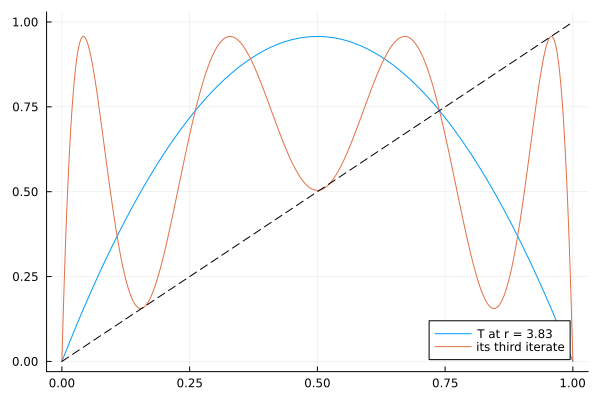

In [38]:
Klog = 128
NX = 2^20

rlog = interval(3.83)
Tlog(x) = rlog*x*(1-x)

plot(x -> IntervalArithmetic.mid(Tlog(x)), 0, 1; label = "T at r = 3.83")
plot!(x -> IntervalArithmetic.mid(Tlog(Tlog(Tlog(x)))), 0, 1; label = "its third iterate")
plot!(x -> x, 0, 1; label = "", color = :black, linestyle = :dash)

The three points where the third iterate crosses the diagonal with a small slope are the cycle.

`FourierAdjoint(K, N)` samples the integrand of
$$
P_{k,\ell} = \frac{1}{2}\int_{-1}^{1} e_k(T(x))\,e_\ell(x)\,dx, \qquad e_k(x) = e^{k\pi i x},
$$
on $N$ equispaced points and takes the discrete transform, so the entries it returns are exact up to the aliasing
$$
\mathcal{F}_N(f)[\ell] - \mathcal{F}(f)[\ell] = \sum_{q\neq 0}\mathcal{F}(f)[\ell + qN],
$$
which the interval radii of the assembled matrix do not cover: those radii are $4\cdot 10^{-13}$ and track the arithmetic alone.
The map is continuous at the identification and its derivative is not, $T'$ jumping by $2r$ there, so $f_k = e_k\circ T$ has a corner and its coefficients decay like $|\ell|^{-2}$ rather than exponentially; the trapezoidal rule is second order and the oversampling has to be generous.
We take $N = 2^{18}$ for $K = 128$, and we bound the aliasing below, since it is the quantity that decides how sharply the operator eigenvalues can be enclosed.

In [39]:
Blog = FourierAdjoint(Klog, NX)
@time PKlog = assemble(Blog, Tlog)
bPKlog = BallMatrix(PKlog)
maximum(bPKlog.r)

127.301097 seconds (442.07 M allocations: 61.246 GiB, 8.58% gc time, 0.05% compilation time)


┌ Warning: This basis breaks the usual interface of the package, i.e.,
│     the dynamic is input as a function instead than a PwMap
└ @ RigorousInvariantMeasures /home/isaia/.julia/packages/RigorousInvariantMeasures/snZmj/src/Basis/Fourier/FourierAdjoint.jl:22


4.060357995581691e-13

We compute the eigenvalues of the matrix numerically and treat them as an oracle. They are not certified, and nothing in what follows certifies them; they are floating point numbers that say where to draw the circles, and they enter nothing else. What the certificate takes is a centre and a radius: it bounds the resolvent of the discretization on that circle, and Proposition A.7 turns the bound into one for the resolvent of the operator, from which it follows that the operator and its discretization have the same number of eigenvalues inside the circle. The centre may be any complex number, so an oracle that is merely plausible does the job, and no verified eigenvalue algorithm is needed.

In [40]:
function peripheral(bP, σ, K)
    A = BallMatrix(NoiseInterval(σ, K))*bP
    F = eigen(BallArithmetic.mid(A))
    p = sortperm(abs.(F.values), rev = true)
    return (A = A, F = F, p = p)
end

peripheral (generic function with 1 method)

In [41]:
σs = [0.02, 0.03, 0.05, 0.08, 0.12]
@time results = [peripheral(bPKlog, interval(s), Klog) for s in σs]
length(results)

  0.796457 seconds (1.82 M allocations: 206.564 MiB, 34.23% compilation time)


5

The plot below shows the computed eigenvalues; the crosses are the three cube roots of $1$.

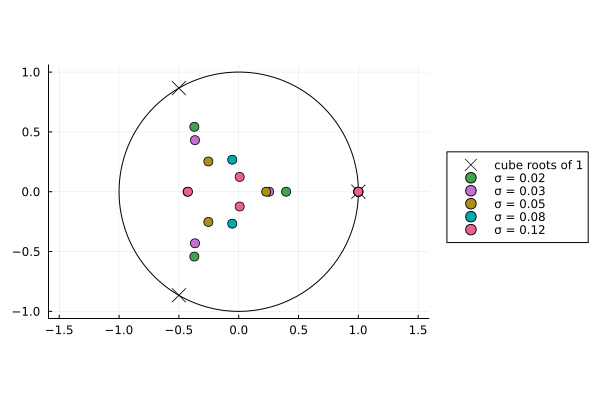

In [42]:
pl = plot([cos(t) for t in 0:0.01:2π], [sin(t) for t in 0:0.01:2π];
          label = "", color = :black, aspect_ratio = 1, legend = :outerright)
scatter!(pl, [1.0, cos(2π/3), cos(4π/3)], [0.0, sin(2π/3), sin(4π/3)];
         label = "cube roots of 1", marker = (:xcross, 7), color = :black)
for (s, res) in zip(σs, results)
    λs = res.F.values[res.p[1:4]]
    scatter!(pl, real.(λs), imag.(λs); label = "σ = $s", marker = 5)
end
pl

The three peaks of the stationary density at the smallest noise size are the three points of the cycle.

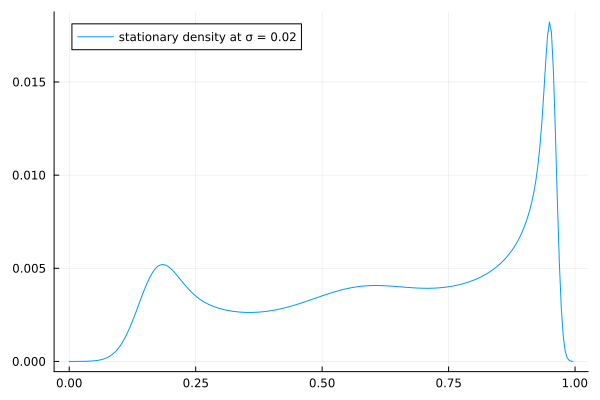

In [43]:
res₀ = results[1]
f₀ = symmetrise(res₀.F.vectors[:, res₀.p[1]]/res₀.F.vectors[1, res₀.p[1]])
plot(range(0, 1; length = 2Klog+2)[1:end-1], real.(ifft(f₀));
     label = "stationary density at σ = 0.02")

# From the matrix to the operator

Nothing so far is a statement about $P_\sigma$: an eigenvalue of a $257\times 257$ matrix is an eigenvalue of a $257\times 257$ matrix.

The bridge to the operator is one inequality. Write $P_{\sigma,k}$ for the finite rank operator we actually hold, $R(z, P_{\sigma,k}) = \|(z-P_{\sigma,k})^{-1}\|$ for its resolvent, and let $\delta_k$ be a number with $\delta_k \geq \|P_\sigma - P_{\sigma,k}\|$. If
$$
R(z, P_{\sigma,k})\,\delta_k < 1 \qquad \text{for every } z \text{ on a closed contour } \Gamma,
$$
then $\Gamma$ lies in the resolvent set of $P_\sigma$, and $P_\sigma$ has inside $\Gamma$ exactly as many eigenvalues, counted with multiplicity, as $P_{\sigma,k}$ has. The reason is that the whole segment $P_{\sigma,k} + t(P_\sigma - P_{\sigma,k})$, $t\in[0,1]$, keeps $\Gamma$ in its resolvent set under the same inequality, so its Riesz projector is continuous in $t$, and a norm continuous family of projectors has constant rank.

Everything else is the work of producing the two numbers. Write $\widetilde P_{\sigma,k}$ for the exact Fourier truncation of $P_\sigma$, the operator whose entries are the true integrals, and $P_{\sigma,k}$ for the matrix we actually hold, whose entries are those integrals computed with an $N$ point transform. Then
$$
\delta_k \;\leq\; \|P_\sigma - \widetilde P_{\sigma,k}\| \;+\; \|\widetilde P_{\sigma,k} - P_{\sigma,k}\|,
$$
both norms taken from the strong space into the weak one. The first term is the Fourier tail $\tau_K$, what we lose by keeping $2K+1$ modes; the Gaussian makes it exponentially small in $\sigma^2K^2$, $10^{-14}$ at $\sigma = 0.02$ and $10^{-162}$ at $\sigma = 0.12$, so it is never what binds. The second is the aliasing $\varepsilon_{\rm alias}$, what the quadrature of the assembler loses, and it falls like $N^{-2}$ in the oversampling; it is the term that decides whether a given circle can be certified. A third constant $b_K$ bounds the coupling of the kept modes to the rest, which the block triangular form of the truncation carries, and $R$ comes from the certified singular values below. The three estimates are taken from [Nisoli](https://arxiv.org/abs/2602.19435), [Blumenthal, Nisoli, Taylor-Crush](https://arxiv.org/abs/2507.09021) and [Galatolo, Lopez Vereau, Marangio, Nisoli](https://doi.org/10.1137/25M1786441), where they are derived.

### Where the condition comes from

The inequality above is the case in which the two norms coincide, and the statement behind it does not need that. Let $(\mathcal{B}_s, \|\cdot\|_s) \hookrightarrow (\mathcal{B}_w, \|\cdot\|_w)$ be a continuous embedding with constant $E_{s\to w}$, and suppose that $P_\sigma$ and its discretization both satisfy the pair
$$
\|P u\|_s \leq a\|u\|_s + b\|u\|_w, \qquad \|P u\|_w \leq M\|u\|_w,
$$
the first of which is the Lasota-Yorke inequality of the previous lectures. Write $\delta_k := \|P_\sigma - P_{\sigma,k}\|_{s\to w}$ for the discrepancy measured from the strong space into the weak one, and $R_w(z, P_{\sigma,k})$ for the resolvent of the discretization in the weak norm. Proposition A.7 of [Nisoli](https://arxiv.org/abs/2602.19435) states that if
$$
|z| > a + b\,R_w(z, P_{\sigma,k})\,\delta_k,
$$
then $z$ belongs to the resolvent set of $P_\sigma$ on the strong space, and
$$
R_s(z, P_\sigma) \;\leq\; \frac{b\,R_w(z, P_{\sigma,k})\,E_{s\to w} + 1}{|z| - a - b\,R_w(z, P_{\sigma,k})\,\delta_k}.
$$

The noise here smooths in one step, so $a = 0$, as the uniform kernel of the previous lecture also had $A = 0$; the condition becomes
$$
b\,R_w(z, P_{\sigma,k})\,\delta_k < |z|,
$$
which is the $R\,\delta_k < 1$ we started from, up to the factor $b$ and the modulus of $z$.

The weak space is $L^2$ and the strong space is $\mathcal{A}_\eta$, the functions analytic on an annulus about the unit circle; convolution with the Gaussian is what puts $P_\sigma f$ there, since the multiplier $e^{-\sigma^2\pi^2k^2/2}$ beats $e^{-\eta|k|}$ for every $\eta$, so $P_\sigma$ sends $L^2$ into $\mathcal{A}_\eta$ in one step and no strong norm survives on the right, which is the $a = 0$ above. The width of the annulus is not free, and it is the noise that sets it: the constant of that step is
$$
b(\eta) = \sup_k e^{-\sigma^2\pi^2k^2/2}\,e^{\eta|k|} = e^{\eta^2/(2\sigma^2\pi^2)},
$$
so $\eta$ may be taken of the order of $\sigma$ at bounded cost and no larger. The embedding has $E_{s\to w} = 1$, since $\|u\|_{L^2} \leq \|u\|_s$; and for the same reason the two numbers we compute below, which are $L^2 \to L^2$ bounds, dominate the mixed norm $\|P_\sigma - P_{\sigma,k}\|_{s\to w}$ that $\delta_k$ asks for.

Two things make the weak resolvent of the discretization the right object to compute. It is computable: $P_{\sigma,k}$ has finite rank, so $R_w(z, P_{\sigma,k})$ is the reciprocal of a smallest singular value of a matrix, which is what the cells below certify. And the weak resolvent of $P_\sigma$ itself would be useless: $P_\sigma$ does not increase the $L^1$ norm, so its weak spectral radius is one and $R_w(z, P_\sigma) = \infty$ for every $|z| \leq 1$, which is exactly where the eigenvalues we want to enclose lie. The Lasota-Yorke pair is what turns a quantity we can compute into a bound on one we cannot.

In [44]:
# The three pieces of δ_k = ‖P_σ - P_{σ,k}‖_{A_η → L²}, and the constant b of the
# Lasota-Yorke pair. Ck is the C² constant of e_k∘T on [-1,1] for T(y) = (r/2)(1-y²)-1,
# whose derivative jumps by 2r at the identification; the aliasing of the N point
# transform is then π²Ck/(3N²) per entry, damped by the noise row by row, and we take
# the Frobenius norm of that to bound the 2-norm.
Ck(k, r) = 2*abs(interval(k))*r/interval(π) + interval(k)^2*r^2/interval(3)

alias_bound(K, N, σ, r) = sqrt(interval(2K+1)*sum(
    exp(-σ^2*interval(π)^2*interval(k)^2)*(interval(π)^2*Ck(k, r)/(interval(3)*interval(N)^2))^2
    for k in -K:K))

# the modes above K, from |F(P_σ f)[k]| ≤ exp(-σ²π²k²/2)‖f‖ and
# k² ≥ (K+1)² + (2K+1)(k-K-1)
function tail_bound(K, σ)
    c = σ^2*interval(π)^2
    return sqrt(interval(2)*exp(-c*interval(K+1)^2)/(interval(1) - exp(-c*interval(2K+1))))
end

# b = ‖ρ_σ‖_{A_η}, with the strong norm ‖u‖_s² = Σ_k exp(2η|k|)|û_k|². The two exponents
# are combined before exponentiating: exp(2η|k|) alone overflows long before the product
# with exp(-σ²π²k²) has become negligible.
b_Aη(η, σ, K) = sqrt(sum(exp(interval(2)*η*interval(abs(k)) - σ^2*interval(π)^2*interval(k)^2)
                         for k in -4K:4K))

# ‖P_σ(I - Π_K)‖_{s→w}, using ‖(I - Π_K)u‖_{L²} ≤ exp(-ηK)‖u‖_s
ρ_L2(σ, K) = sqrt(sum(exp(-σ^2*interval(π)^2*interval(k)^2) for k in -4K:4K))
trunc_bound(η, σ, K) = ρ_L2(σ, K)*exp(-η*interval(K))

δ_bound(η, σ, K, N, r) = tail_bound(K, σ) + trunc_bound(η, σ, K) + alias_bound(K, N, σ, r)

δ_bound (generic function with 1 method)

In [45]:
σ₁ = interval(0.12)
η  = argmin(t -> sup(b_Aη(interval(t), σ₁, Klog)*δ_bound(interval(t), σ₁, Klog, NX, rlog)),
            0.02:0.005:0.6)
b  = sup(b_Aη(interval(η), σ₁, Klog))
δ  = sup(δ_bound(interval(η), σ₁, Klog, NX, rlog))

(η = η, b = b, δ_k = δ,
 tail = sup(tail_bound(Klog, σ₁)),
 truncation = sup(trunc_bound(interval(η), σ₁, Klog)),
 aliasing = sup(alias_bound(Klog, NX, σ₁, rlog)))

(η = 0.19, b = 3.028719313516157, δ_k = 3.601578035848714e-9, tail = 3.8499310870764165e-162, truncation = 5.944017904286912e-11, aliasing = 3.542137856805845e-9)

The contour is a circle around a computed eigenvalue, and `run_certification` of `BallArithmetic.CertifScripts` bounds $\sigma_{\min}(zI-\widetilde A)$ on all of it. It computes the Schur form of $\widetilde A$ once, with certified bounds on the orthogonality defect and on the reconstruction error, then walks the circle: at each sample it evaluates a certified singular value decomposition of $T-zI$, and it bisects an arc whenever the chord exceeds $\eta$ times the $\sigma_{\min}$ measured at its endpoint. Since $\sigma_{\min}$ is $1$-Lipschitz in $z$, that inequality is what covers the arc between two samples, so the sampling refines by itself where the contour runs close to the spectrum. The bound is then carried from the Schur factor back to $\widetilde A$ by the Schur perturbation theorem, and `resolvent_original` is the result.

What the cell below returns is $R_w(z, P_{\sigma,k})$, the weak resolvent that Proposition A.7 asks for, up to the value $1/|z|$ that the discretization takes off the range of $\Pi_K$, where it vanishes. The three pieces of $\delta_k$ are then added and the criterion is checked once per circle.

In [46]:
# Proposition A.7, with a = 0 and E_{s→w} = 1: the strong resolvent of the operator
# from the weak resolvent of the discretization.
function bridge(Rw, δ, b, absz)
    gap = interval(absz) - interval(b)*interval(Rw)*interval(δ)
    inf(gap) <= 0 && return Inf
    return sup((interval(b)*interval(Rw) + interval(1))/gap)
end

bridge (generic function with 1 method)

In [47]:
# How many eigenvalues the matrix has inside the circle, certified. Along
# A_t = (1-t)Ã + t·Z T Z* the matrix moves by at most errT, which is below the certified
# σ_min on the contour, so Γ stays in the resolvent set and the count does not change;
# Z is invertible since ‖Z*Z - I‖ < 1, so Z T Z* is similar to the triangular T and its
# eigenvalues are exactly the diagonal of T.
function count_inside(schur_data, Rw, λ, ρ)
    S, errF, errT, _, _ = schur_data
    errF < 1 || return missing
    errT < 1/Rw || return missing                 # the homotopy is not covered
    d = diag(S.T)
    all(z -> abs(abs(z - λ) - ρ) > errT, d) || return missing   # none sits on Γ
    return count(z -> abs(z - λ) < ρ, d)
end

function certify_on_circle(bA, λ, ρ; samples = 64, schur_data = nothing)
    out = run_certification(bA, CertificationCircle(λ, ρ; samples = samples);
                            schur_data = schur_data, η = 0.5,
                            log_io = devnull, check_interval = 10^6)
    absz = abs(abs(λ) - ρ)                       # the smallest |z| on the circle
    Rw   = max(out.resolvent_original, 1/absz)   # P_{σ,k} vanishes off the range of Π_K
    Rs   = bridge(Rw, δ, b, absz)
    n    = count_inside(schur_data, out.resolvent_original, λ, ρ)
    println(round(λ, digits = 7), "   ρ = ", ρ,
            "   samples = ", length(out.certification_log),
            "   R_w = ", round(Rw, sigdigits = 5),
            "   b R_w δ_k = ", round(b*Rw*δ, sigdigits = 3),
            "   |z| = ", round(absz, sigdigits = 5),
            isinf(Rs) ? "   fails" :
              "   R_s(z,P_σ) ≤ " * string(round(Rs, sigdigits = 5)) *
              "   eigenvalues inside: " * string(n) * "   proved")
    return out
end

A₁  = results[end].A                               # σ = 0.12
sd₁ = compute_schur_and_error(A₁)                  # once, reused by every circle
# the certification needs this decomposition anyway, so we read the oracle off its
# diagonal rather than calling `eigen` a second time at this noise size
λ₁  = sort(diag(sd₁[1].T); by = abs, rev = true)

257-element Vector{ComplexF64}:
      1.0000000000000002 + 0.0im
    -0.42432878430669063 + 4.440892098500626e-16im
     0.00804979396540422 + 0.12367870912629525im
    0.008049793965408752 - 0.12367870912629392im
    0.028154764076967882 + 0.030790264836237997im
     0.02815476407695025 - 0.03079026483622575im
  -0.0016121041002656593 + 4.4558483964195206e-12im
 -0.00023272225910196074 - 0.0002521122439951153im
  -0.0002327221627477748 + 0.00025211232920527223im
  0.00014129797547653212 + 1.7175745248404052e-11im
                         ⋮
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im
                     0.0 + 0.0im

We certify at one noise size, $\sigma = 0.12$, which is enough to show what the enclosure does. There the moduli are $1$, $0.4243288$, $0.1239404$ twice and then $0.0417221$ twice, so four eigenvalues sit outside the gap: the fixed point, the real eigenvalue $-0.4243288$, and the conjugate pair $0.0080498 \mp 0.1236787i$. The pair sits where the resolvent is largest, so its two circles are the expensive ones.

In [48]:
@time certify_on_circle(A₁, λ₁[1], 3e-5; schur_data = sd₁);

┌ Info: The ϵ in the Schur theorems 4.981085614922874e-12
└ @ BallArithmetic.CertifScripts /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/pseudospectra/CertifScripts.jl:992


1.0 + 0.0im   ρ = 3.0e-5   samples = 64   R_w = 140220.0   b R_w δ_k = 0.00153   |z| = 0.99997   R_s(z,P_σ) ≤ 425350.0   eigenvalues inside: 1   proved
  9.437293 seconds (9.98 M allocations: 21.423 GiB, 15.65% gc time, 10.63% compilation time)


In [49]:
@time certify_on_circle(A₁, λ₁[2], 1e-5; schur_data = sd₁);

┌ Info: The ϵ in the Schur theorems 4.981085614922874e-12
└ @ BallArithmetic.CertifScripts /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/pseudospectra/CertifScripts.jl:992


-0.4243288 + 0.0im   ρ = 1.0e-5   samples = 128   R_w = 3.92e6   b R_w δ_k = 0.0428   |z| = 0.42432   R_s(z,P_σ) ≤ 3.1116e7   eigenvalues inside: 1   proved
 18.672795 seconds (5.53 M allocations: 42.147 GiB, 16.39% gc time)


In [50]:
@time certify_on_circle(A₁, λ₁[3], 1e-3; schur_data = sd₁);

┌ Info: The ϵ in the Schur theorems 4.981085614922874e-12
└ @ BallArithmetic.CertifScripts /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/pseudospectra/CertifScripts.jl:992


0.0080498 + 0.1236787im   ρ = 0.001   samples = 4096   R_w = 915510.0   b R_w δ_k = 0.00999   |z| = 0.12294   R_s(z,P_σ) ≤ 2.4548e7   eigenvalues inside: 1   proved
560.186074 seconds (178.48 M allocations: 1.317 TiB, 17.10% gc time)


This one is slow. Recorded from a run of the cell above:

```
0.0080498 + 0.1236787im   ρ = 0.001   samples = 4096   R_w = 915510.0   b R_w δ_k = 0.00999   |z| = 0.12294   R_s(z,P_σ) ≤ 2.4548e7   proved
```

in 5 minutes and 33 seconds. This eigenvalue is about three hundred times worse conditioned than the fixed point, so the refinement reaches 4096 samples where the circles above needed 64 and 128. The result is written here so that the notebook can be read without waiting; run the cell yourself when you have the time.

In [51]:
@time certify_on_circle(A₁, λ₁[4], 1e-3; schur_data = sd₁);

┌ Info: The ϵ in the Schur theorems 4.981085614922874e-12
└ @ BallArithmetic.CertifScripts /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/pseudospectra/CertifScripts.jl:992


0.0080498 - 0.1236787im   ρ = 0.001   samples = 4096   R_w = 915510.0   b R_w δ_k = 0.00999   |z| = 0.12294   R_s(z,P_σ) ≤ 2.4548e7   eigenvalues inside: 1   proved
406.254025 seconds (178.48 M allocations: 1.317 TiB, 21.00% gc time)


This one is slow. Recorded from a run of the cell above:

```
0.0080498 - 0.1236787im   ρ = 0.001   samples = 4096   R_w = 915510.0   b R_w δ_k = 0.00999   |z| = 0.12294   R_s(z,P_σ) ≤ 2.4548e7   proved
```

in 4 minutes and 48 seconds. The result is written here so that the notebook can be read without waiting; run the cell yourself when you have the time.

The circles above enclose one eigenvalue each; they do not say that these are the four of largest modulus. That needs a contour with the four outside and the rest inside, and since the next modulus down is $0.0417221$, any radius between it and $0.1239404$ will do. We take the geometric mean.

In [52]:
rsep₁ = sqrt(abs(λ₁[3])*abs(λ₁[5]))
@time certify_on_circle(A₁, 0.0+0.0im, rsep₁; schur_data = sd₁);

┌ Info: The ϵ in the Schur theorems 4.981085614922874e-12
└ @ BallArithmetic.CertifScripts /home/isaia/.julia/packages/BallArithmetic/MiiqO/src/pseudospectra/CertifScripts.jl:992


0.0 + 0.0im   ρ = 0.07191001320781107   samples = 23969   R_w = 122350.0   b R_w δ_k = 0.00133   |z| = 0.07191   R_s(z,P_σ) ≤ 5.2506e6   eigenvalues inside: 253   proved
1797.468242 seconds (1.04 G allocations: 7.708 TiB, 24.51% gc time)


This one is slow. Recorded from a run of the cell above:

```
0.0 + 0.0im   ρ = 0.07191001320781107   samples = 23969   R_w = 122350.0   b R_w δ_k = 0.00133   |z| = 0.07191   R_s(z,P_σ) ≤ 5.2506e6   proved
```

in 27 minutes and 50 seconds. The contour runs close to the spectrum on both sides, so the adaptive refinement takes it to 23969 samples. The result is written here so that the notebook can be read without waiting; run the cell yourself when you have the time.

The picture, with the eigenvalues of the matrix as the oracle gives them, the four we enclosed marked, and the separating circle dashed. At the scale of the unit disc the separating circle is small, since at this noise size everything but $1$ and $-0.4243288$ already lies within $0.125$ of the origin; the middle panel is the scale at which it separates, with the pair outside it and the two eigenvalues of modulus $0.0417221$ inside. The right panel is the certified circle about $\lambda_3$ at its own scale, $10^{-3}$, where the enclosure is what the picture shows.

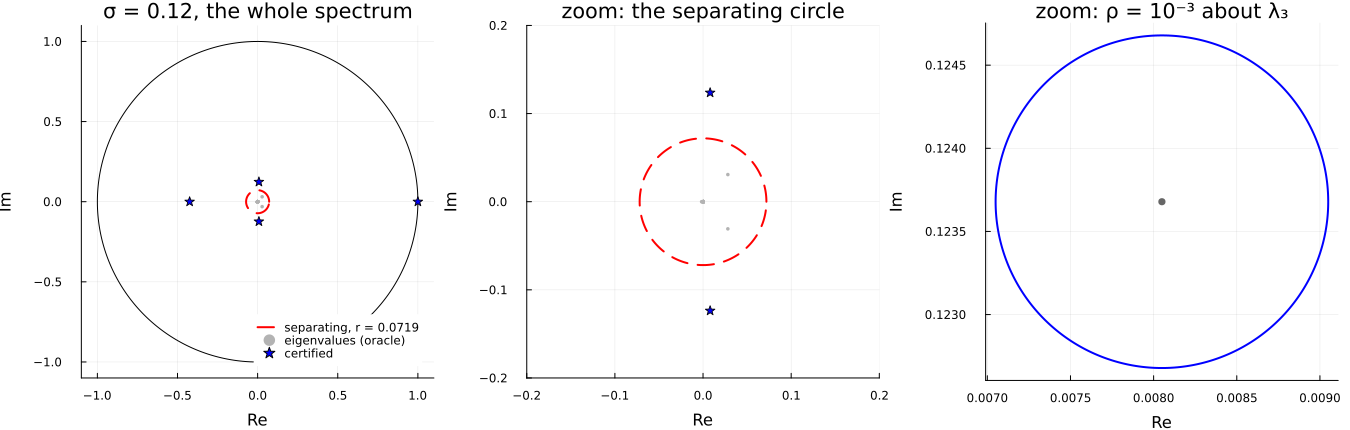

In [53]:
cert = [(λ₁[1], 3e-5), (λ₁[2], 1e-5), (λ₁[3], 1e-3), (λ₁[4], 1e-3)]
circ(c, r) = (real(c) .+ r*cos.(0:0.005:2π), imag(c) .+ r*sin.(0:0.005:2π))
cx = [real(c) for (c, _) in cert]; cy = [imag(c) for (c, _) in cert]

function panel(lim, ttl; unit = false)
    p = plot(; aspect_ratio = 1, xlims = (-lim, lim), ylims = (-lim, lim),
             xlabel = "Re", ylabel = "Im", title = ttl, legend = false)
    unit && plot!(p, circ(0, 1)...; color = :black, lw = 1, label = "")
    plot!(p, circ(0, rsep₁)...; color = :red, lw = 2, ls = :dash, label = "")
    scatter!(p, real.(λ₁), imag.(λ₁); markersize = 2, color = :grey70,
             markerstrokewidth = 0, label = "")
    scatter!(p, cx, cy; markersize = 5, color = :blue, marker = :star5, label = "")
    p
end

p1 = panel(1.1,  "σ = 0.12, the whole spectrum"; unit = true)
p2 = panel(0.20, "zoom: the separating circle")
c₀, ρ₀ = cert[3]
p3 = plot(circ(c₀, ρ₀)...; color = :blue, lw = 2, aspect_ratio = 1, legend = false,
          xlabel = "Re", ylabel = "Im", title = "zoom: ρ = 10⁻³ about λ₃")
scatter!(p3, [real(c₀)], [imag(c₀)]; markersize = 4, color = :grey40, markerstrokewidth = 0)

plot!(p1; legend = :bottomright, foreground_color_legend = nothing)
plot!(p1, [NaN], [NaN]; color = :red, ls = :dash, lw = 2,
      label = "separating, r = $(round(rsep₁, digits = 4))")
scatter!(p1, [NaN], [NaN]; color = :grey70, markersize = 2, markerstrokewidth = 0,
         label = "eigenvalues (oracle)")
scatter!(p1, [NaN], [NaN]; color = :blue, marker = :star5, markersize = 5, label = "certified")
plot(p1, p2, p3; layout = (1, 3), size = (1350, 430),
     left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

What the five contours give is this. The bound on the resolvent of the discretization puts each circle in its resolvent set, Proposition A.7 puts the same circle in the resolvent set of $P_\sigma$, and the condition holds along the whole segment $P_{\sigma,k}+t(P_\sigma-P_{\sigma,k})$, $t\in[0,1]$, so the Riesz projector of that family is continuous in $t$ and its rank is constant. Inside each circle, therefore, the operator and its discretization have the same number of eigenvalues, counted with multiplicity.

For the four small circles that is the useful reading: none of them contains the origin, and each contains one eigenvalue of the matrix, so if the oracle has counted right, $P_\sigma$ has exactly one eigenvalue within $3\cdot10^{-5}$ of $1$, one within $10^{-5}$ of $-0.4243288$, and one within $10^{-3}$ of each of $0.0080498 \mp 0.1236787i$. The separating circle contains the origin, where $P_{\sigma,k}$ has an eigenvalue of infinite multiplicity, since it has finite rank, and where the eigenvalues of the compact operator $P_\sigma$ accumulate; inside it the count is infinite on both sides and says nothing, and the statement with content is the complementary one, that the two have the same finite number of eigenvalues outside.

The count itself is the oracle's and is not certified here. Certifying it is a separate finite computation on the matrix, and the Schur form we already hold would carry it: the eigenvalues of a triangular factor are its diagonal entries, and the reconstruction error $\|ZTZ^* - \widetilde A\| \leq 5\cdot10^{-12}$ is far below the distance from any of those entries to any of our contours.

Every one of the five contours passes the criterion with room. With $\eta = 0.19$ we have $b = \|\rho_\sigma\|_{\mathcal{A}_\eta} = 3.03$ and $\delta_k = 3.60\cdot10^{-9}$, of which the aliasing is $3.54\cdot10^{-9}$, the truncation $5.9\cdot10^{-11}$ and the Fourier tail $10^{-162}$; the quantity $b\,R_w\,\delta_k$ that has to stay below $|z|$ comes out at $0.00153$ against $1$ on the circle about the fixed point, $0.0428$ against $0.4243$ about $-0.4243288$, $0.00999$ against $0.1229$ about each member of the pair, and $0.00133$ against $0.0719$ on the separating circle. The aliasing is what dominates $\delta_k$, and it falls like $N^{-2}$, so a smaller $\rho$ is bought with more oversampling and with nothing else.

# Summary of the lecture

We discretized the annealed transfer operator of a random system with Gaussian noise on a Fourier basis, where the noise is diagonal and the truncation error is exponentially small in $K^2$, and we worked throughout in ball arithmetic.

From certified singular values of the powers of the operator restricted to the zero average subspace we obtained a mixing rate, a proved pair $(n, \eta)$ with $\|P^n|_V\| \leq \eta < 1$; the first power has norm above one although the spectral radius is about one half, which is what non-normality does and what the pseudospectrum picture shows.

The mixing rate, the residual of an approximate fixed point and the truncation constants gave an $L^2$ bound on the distance between the computed density and the true one, and the Fourier coefficients of $\log|T'|$, enclosed with Taylor models, turned that into an enclosure of the Lyapunov exponent.

The closing section took the logistic map at $r = 3.83$, a parameter inside the period three window, and enclosed the peripheral eigenvalues of its annealed operator, not of its matrix: a necklace of overlapping discs around a circle, one Rump certified singular value decomposition per disc, and a small gain condition that carries the bound from the truncation to the operator. What limits the enclosure is the aliasing of the Fourier assembler, bounded by the estimate of the paper above and falling like $N^{-2}$ in the oversampling.